In [ ]:
import os
import numpy as np
import pandas as pd
from scipy.sparse import load_npz, csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_DIR = "/content/drive/MyDrive/PixelRec50K"
PROCESSED_DIR = os.path.join(DATASET_DIR, "processed")
RESULT_DIR = os.path.join(DATASET_DIR, "results")

In [ ]:
train_df = pd.read_csv(os.path.join(PROCESSED_DIR, "train_5core.csv"))
val_df = pd.read_csv(os.path.join(PROCESSED_DIR, "val_5core.csv"))
test_df = pd.read_csv(os.path.join(PROCESSED_DIR, "test_5core.csv"))

train_samples = pd.read_csv(os.path.join(PROCESSED_DIR, "train_samples_5core.csv"))
val_samples = pd.read_csv(os.path.join(PROCESSED_DIR, "val_samples_5core.csv"))
test_samples = pd.read_csv(os.path.join(PROCESSED_DIR, "test_samples_5core.csv"))

train_matrix = load_npz(os.path.join(PROCESSED_DIR, "train_interaction_matrix_5core.npz"))

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)
print("Train samples:", train_samples.shape)
print("Validation samples:", val_samples.shape)
print("Test samples:", test_samples.shape)
print("Train matrix:", train_matrix.shape, "| non-zeros:", train_matrix.nnz)

display(train_samples.head())

Train: (711060, 6)
Validation: (89743, 6)
Test: (113024, 6)
Train samples: (1422120, 3)
Validation samples: (538458, 3)
Test samples: (678144, 3)
Train matrix: (49950, 47322) | non-zeros: 711060


,user_idx,item_idx,label
0,19495,23534,0
1,21385,28764,0
2,44596,10423,0
3,4394,6388,0
4,42477,5673,0


# Item Based CF

**Item-Based Collaborative Filtering**

In item-based collaborative filtering, items are considered similar if they were interacted with by similar groups of users.

The training matrix has the shape:

users × items

To compute item-item similarity, we transpose the matrix into:

items × users

Then we calculate cosine similarity between item vectors. Each item vector represents which users interacted with that item.

In [ ]:
# Compute item-item cosine similarity
# train_matrix shape: users x items
# train_matrix.T shape: items x users

item_similarity = cosine_similarity(train_matrix.T, dense_output=False)

print("Item similarity matrix shape:", item_similarity.shape)
print("Number of nonzero similarities:", item_similarity.nnz)

Item similarity matrix shape: (47322, 47322)
Number of nonzero similarities: 16928214


In [ ]:
#try with one user
user_idx = 0

# Get the user's training interaction vector
user_vector = train_matrix[user_idx]

# Score all items based on similarity to items the user has interacted with
scores = user_vector @ item_similarity

# Convert to dense array for ranking
scores = scores.toarray().ravel()

# Remove items already seen in training
seen_items = user_vector.indices
scores[seen_items] = -np.inf

# Get top 10 recommended item indices
top_k = 10
recommended_items = np.argsort(scores)[::-1][:top_k]

print("User:", user_idx)
print("Number of seen items in train:", len(seen_items))
print("Top recommended item_idx:", recommended_items)
print("Recommendation scores:", scores[recommended_items])

User: 0
Number of seen items in train: 11
Top recommended item_idx: [27218 46850  5664 38755 34980 34963 35563 39859 44403 19468]
Recommendation scores: [0.26729605 0.25337797 0.23435546 0.23135489 0.2139363  0.18890049
 0.18708155 0.18708155 0.18426189 0.17932186]


## Evaluation function for sampled candidate sets

In [ ]:
def precision_at_k(ranked_items, relevant_items, k):
    """
    Compute Precision@K for one user.
    """
    ranked_k = ranked_items[:k]
    relevant_set = set(relevant_items)

    if k == 0:
        return 0.0

    hits = sum(1 for item in ranked_k if item in relevant_set)
    return hits / k


def recall_at_k(ranked_items, relevant_items, k):
    """
    Compute Recall@K for one user.
    """
    ranked_k = ranked_items[:k]
    relevant_set = set(relevant_items)

    if len(relevant_set) == 0:
        return 0.0

    hits = sum(1 for item in ranked_k if item in relevant_set)
    return hits / len(relevant_set)


def ndcg_at_k(ranked_items, relevant_items, k):
    """
    Compute NDCG@K for one user.
    """
    relevant_set = set(relevant_items)
    dcg = 0.0

    for rank, item in enumerate(ranked_items[:k], start=1):
        if item in relevant_set:
            dcg += 1.0 / np.log2(rank + 1)

    ideal_hits = min(len(relevant_set), k)
    idcg = sum(1.0 / np.log2(rank + 1) for rank in range(1, ideal_hits + 1))

    return dcg / idcg if idcg > 0 else 0.0


def score_item_cf_for_user_candidates(user_idx, candidate_items, train_matrix, item_similarity):
    """
    Score only the sampled candidate items for one user using item-based CF.
    This matches the sampled candidate evaluation setting used by other models.
    """
    user_vector = train_matrix[user_idx]

    scores = user_vector @ item_similarity
    scores = scores.toarray().ravel()

    seen_items = user_vector.indices
    scores[seen_items] = -np.inf

    return scores[candidate_items]


def evaluate_item_cf_on_samples(train_matrix, item_similarity, samples_df, k_values=[5, 10, 20]):
    """
    Evaluate item-based CF on sampled candidate sets.

    samples_df must contain:
    - user_idx
    - item_idx
    - label

    For each user, the model ranks only the candidate items in samples_df.
    This makes the evaluation comparable to baseline, NMF, and LightFM.
    """
    rows = []

    for user_idx, user_data in tqdm(samples_df.groupby("user_idx")):
        if user_idx >= train_matrix.shape[0]:
            continue

        candidate_items = user_data["item_idx"].values.astype(np.int32)
        relevant_items = user_data.loc[user_data["label"] == 1, "item_idx"].unique().tolist()

        if len(candidate_items) == 0 or len(relevant_items) == 0:
            continue

        scores = score_item_cf_for_user_candidates(
            user_idx=user_idx,
            candidate_items=candidate_items,
            train_matrix=train_matrix,
            item_similarity=item_similarity
        )

        ranked_items = candidate_items[np.argsort(-scores)].tolist()

        for k in k_values:
            rows.append({
                "user_idx": user_idx,
                "k": k,
                "precision": precision_at_k(ranked_items, relevant_items, k),
                "recall": recall_at_k(ranked_items, relevant_items, k),
                "ndcg": ndcg_at_k(ranked_items, relevant_items, k)
            })

    user_results = pd.DataFrame(rows)

    summary = (
        user_results
        .groupby("k")[["precision", "recall", "ndcg"]]
        .mean()
        .reset_index()
    )

    summary["evaluated_users"] = user_results.groupby("k")["user_idx"].nunique().values

    return summary, user_results

# Training Result

## Validation results under sampled candidate evaluation

In [ ]:
cf_val_summary, cf_val_user_results = evaluate_item_cf_on_samples(
    train_matrix=train_matrix,
    item_similarity=item_similarity,
    samples_df=val_samples,
    k_values=[5, 10, 20]
)

cf_val_summary["model"] = "Item-Based Collaborative Filtering"
cf_val_summary["features"] = "User-item interaction matrix with item-item cosine similarity"
cf_val_summary["split"] = "validation"

cf_val_summary = cf_val_summary[
    ["model", "features", "split", "k", "precision", "recall", "ndcg", "evaluated_users"]
]

display(cf_val_summary)

100%|██████████| 49718/49718 [01:00<00:00, 817.10it/s] 


,model,features,split,k,precision,recall,ndcg,evaluated_users
0,Item-Based Collaborative Filtering,User-item interaction matrix with item-item co...,validation,5,0.209425,0.719260,0.530715,49718
1,Item-Based Collaborative Filtering,User-item interaction matrix with item-item co...,validation,10,0.140941,0.903777,0.601075,49718
2,Item-Based Collaborative Filtering,User-item interaction matrix with item-item co...,validation,20,0.083201,0.980226,0.629151,49718


## Test results under sampled candidate evaluation

In [ ]:
cf_test_summary, cf_test_user_results = evaluate_item_cf_on_samples(
    train_matrix=train_matrix,
    item_similarity=item_similarity,
    samples_df=test_samples,
    k_values=[5, 10, 20]
)

cf_test_summary["model"] = "Item-Based Collaborative Filtering"
cf_test_summary["features"] = "User-item interaction matrix with item-item cosine similarity"
cf_test_summary["split"] = "test"

cf_test_summary = cf_test_summary[
    ["model", "features", "split", "k", "precision", "recall", "ndcg", "evaluated_users"]
]

display(cf_test_summary)

100%|██████████| 49950/49950 [00:48<00:00, 1033.68it/s]


,model,features,split,k,precision,recall,ndcg,evaluated_users
0,Item-Based Collaborative Filtering,User-item interaction matrix with item-item co...,test,5,0.193433,0.540996,0.404461,49950
1,Item-Based Collaborative Filtering,User-item interaction matrix with item-item co...,test,10,0.154334,0.807911,0.509532,49950
2,Item-Based Collaborative Filtering,User-item interaction matrix with item-item co...,test,20,0.100611,0.963471,0.565720,49950


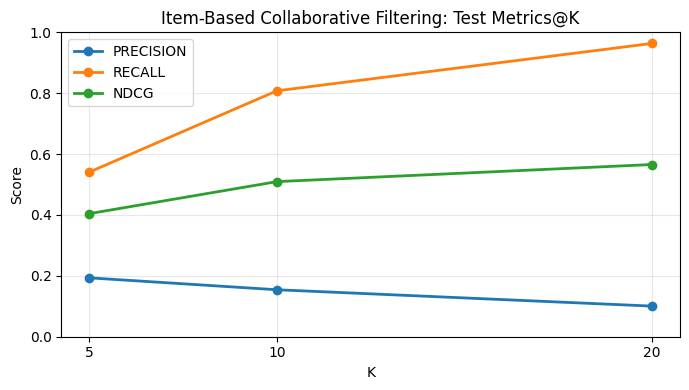

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

metrics = ["precision", "recall", "ndcg"]

for metric in metrics:
    plt.plot(
        cf_test_summary["k"],
        cf_test_summary[metric],
        marker="o",
        linewidth=2,
        label=metric.upper()
    )

plt.title("Item-Based Collaborative Filtering: Test Metrics@K")
plt.xlabel("K")
plt.ylabel("Score")
plt.xticks(cf_test_summary["k"])
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
cf_results_df = pd.concat(
    [cf_val_summary, cf_test_summary],
    ignore_index=True
)

display(cf_results_df)

cf_results_df.to_csv(
    os.path.join(RESULT_DIR, "item_cf_sampled_candidate_results.csv"),
    index=False
)

,model,features,split,k,precision,recall,ndcg,evaluated_users
0,Item-Based Collaborative Filtering,User-item interaction matrix with item-item co...,validation,5,0.209425,0.719260,0.530715,49718
1,Item-Based Collaborative Filtering,User-item interaction matrix with item-item co...,validation,10,0.140941,0.903777,0.601075,49718
2,Item-Based Collaborative Filtering,User-item interaction matrix with item-item co...,validation,20,0.083201,0.980226,0.629151,49718
3,Item-Based Collaborative Filtering,User-item interaction matrix with item-item co...,test,5,0.193433,0.540996,0.404461,49950
4,Item-Based Collaborative Filtering,User-item interaction matrix with item-item co...,test,10,0.154334,0.807911,0.509532,49950
5,Item-Based Collaborative Filtering,User-item interaction matrix with item-item co...,test,20,0.100611,0.963471,0.565720,49950


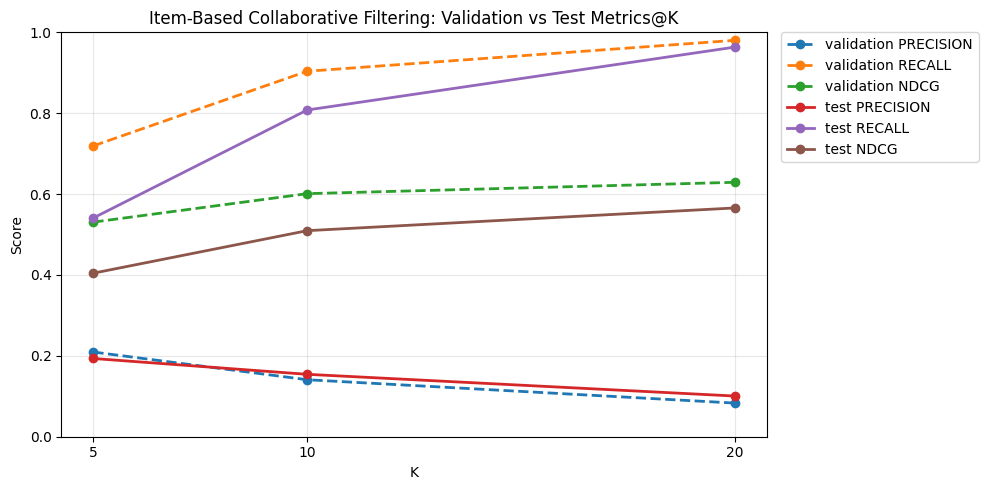

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

cf_eval_summary = pd.concat(
    [cf_val_summary, cf_test_summary],
    ignore_index=True
)

metrics = ["precision", "recall", "ndcg"]

plt.figure(figsize=(10, 5))

for split in ["validation", "test"]:
    subset = cf_eval_summary[cf_eval_summary["split"] == split]

    line_style = "--" if split == "validation" else "-"

    for metric in metrics:
        plt.plot(
            subset["k"],
            subset[metric],
            marker="o",
            linewidth=2,
            linestyle=line_style,
            label=f"{split} {metric.upper()}"
        )

plt.title("Item-Based Collaborative Filtering: Validation vs Test Metrics@K")
plt.xlabel("K")
plt.ylabel("Score")
plt.xticks([5, 10, 20])
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)

# Put legend outside on the right
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()